In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. Load Data

In [2]:
df = pd.read_csv('2020-4-27.csv')

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print(df.columns.tolist())
df.head()

Total rows: 2211
Total columns: 18
['Title', 'Address', 'City', 'Price', 'Bedroom', 'Bathroom', 'Floors', 'Parking', 'Face', 'Year', 'Views', 'Area', 'Road', 'Road Width', 'Road Type', 'Build Area', 'Posted', 'Amenities']


,Title,Address,City,Price,Bedroom,Bathroom,Floors,Parking,Face,Year,Views,Area,Road,Road Width,Road Type,Build Area,Posted,Amenities
0,Flat System House On Sale At Budhanikantha : H...,"Budhanikantha, Budhanilkantha, Kathmandu",Kathmandu,90000000,6,3,2.0,10,West,2073.0,17,1-0-0-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,18-0-0-0 Aana,11 hours ago,"['Parking', 'Lawn', 'Garage', 'Frontyard', 'Fe..."
1,21 Aana Beautiful House : House For Sale In Bu...,"Pasikot, Budhanilkantha, Kathmandu",Kathmandu,80000000,5,3,2.0,9,East,2073.0,26,0-21-0-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,0-14-0-0 Aana,12 hours ago,"['Parking', 'Garage', 'Fencing', 'Frontyard', ..."
2,Beautiful To Floor House : House For Sale In D...,"Dhapasi, Dhapasi, Kathmandu",Kathmandu,70000000,5,3,2.0,12,East,2071.0,154,1-1-0-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,10-1-0-0 Aana,2 days ago,"['Parking', 'Lawn', 'Garage', 'Frontyard', 'Fe..."
3,Modern Architecture Bungalow House : House For...,"baluwatar, Baluwatar, Kathmandu",Kathmandu,130000000,6,4,3.0,9,West,2017.0,17,0-10-1-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,0-7-1-0 Aana,1 day ago,"['Parking', 'Lawn', 'Garage', 'Frontyard', 'Fe..."
4,Modern Bungalow House : House For Sale In Golf...,"Golfutar, Golfutar, Kathmandu",Kathmandu,100000000,6,3,2.0,10,East,2070.0,59,0-19-2-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,0-14-2-0 Aana,2 days ago,"['Parking', 'Lawn', 'Garage', 'Balcony', 'Back..."


### 2. Missing Data Check

In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_report[missing_report['missing_count'] > 0])

           missing_count  missing_pct
Floors              1172         53.0
Year                1629         73.7
Road Type            785         35.5


### 3. Duplicate Check

In [4]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate titles:", df['Title'].duplicated().sum())

Exact duplicate rows: 0
Duplicate titles: 709


### 4. Price Sanity Check (raw, before cleaning)

In [5]:
print(df['Price'].describe())
print("Min price:", df['Price'].min())
print("Max price:", df['Price'].max())
# Note the absurd max value -> evidence of corrupted/scraped data

count    2.211000e+03
mean     4.064428e+11
std      7.564269e+12
min      1.500000e+01
25%      1.300000e+06
50%      8.000000e+06
75%      2.650000e+07
max      2.160000e+14
Name: Price, dtype: float64
Min price: 15
Max price: 216000002700000


### 5. Area Unit Standardization

In [6]:
# Raw 'Area' column mixes Aana (4-part Aana-Paisa-Daam-Anna system),
# Ropani, Sq. Feet, Dhur, Bigha. We convert everything to Aana-equivalent.

def parse_area(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()

    if 'Sq. Feet' in s:
        try:
            val = float(s.replace('Sq. Feet', '').strip())
            return val / 342.25          # 1 Aana ~ 342.25 sq.ft
        except:
            return np.nan

    if 'Ropani' in s:
        try:
            num = s.replace('Ropani', '').strip()
            ropani = float(num.split('-')[0]) if '-' in num else float(num)
            return ropani * 16           # 1 Ropani = 16 Aana
        except:
            return np.nan

    if 'Dhur' in s:
        try:
            val = float(s.replace('Dhur', '').strip())
            return val * 0.339           # approx conversion, Terai unit
        except:
            return np.nan

    if 'Aana' in s:
        try:
            num = s.replace('Aana', '').strip()
            parts = [p for p in num.replace('.', '-').split('-')]
            parts = [float(p) for p in parts if p not in ('', 'N/A')]
            if len(parts) == 4:
                aana, paisa, daam, anna = parts
                return aana + paisa/4 + daam/16 + anna/64
            return parts[0]
        except:
            return np.nan

    return np.nan

df['Area_Aana'] = df['Area'].apply(parse_area)
df['PricePerAana'] = df['Price'] / df['Area_Aana']

print("Unparseable area values:", df['Area_Aana'].isna().sum())

Unparseable area values: 141


### 6. Outlier Treatment (Price)

In [7]:
q1, q3 = df['Price'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

clean = df[(df['Price'] >= 10_000) & (df['Price'] <= upper_bound)].copy()
clean = clean[(clean['Area_Aana'] > 0) & (clean['Area_Aana'] < 200)]  # sanity cap on area too

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(clean)}")
print(f"Rows removed:         {len(df) - len(clean)}")

Rows before cleaning: 2211
Rows after cleaning:  1868
Rows removed:         343


### 7. Core Stats (cleaned data)

In [8]:
print("Mean price:", clean['Price'].mean())
print("Median price:", clean['Price'].median())

top_cities = clean['City'].value_counts().head(5)
print(top_cities)

median_by_city = (
    clean[clean['City'].isin(top_cities.index)]
    .groupby('City')['Price']
    .median()
    .sort_values(ascending=False)
)
print(median_by_city)

Mean price: 13978631.917558886
Median price: 6000000.0
City
Kathmandu    1280
Lalitpur      399
Bhaktapur      76
Pokhara        26
Chitwan        14
Name: count, dtype: int64
City
Kathmandu    9500000.0
Pokhara      7550000.0
Chitwan      5000000.0
Lalitpur     4000000.0
Bhaktapur    1800000.0
Name: Price, dtype: float64


### 8. Visualization 1: Price Distribution + Listings by City

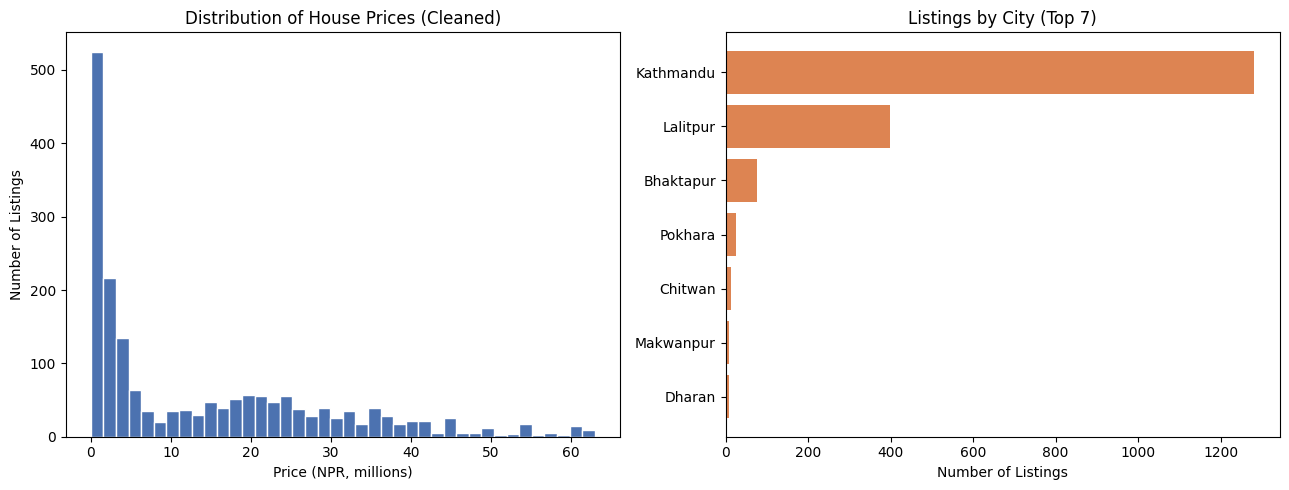

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(clean['Price'] / 1e6, bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of House Prices (Cleaned)')
axes[0].set_xlabel('Price (NPR, millions)')
axes[0].set_ylabel('Number of Listings')

top7 = clean['City'].value_counts().head(7)
axes[1].barh(top7.index[::-1], top7.values[::-1], color='#DD8452')
axes[1].set_title('Listings by City (Top 7)')
axes[1].set_xlabel('Number of Listings')

plt.tight_layout()
plt.savefig('visualizations1.png', dpi=140)
plt.show()

### 9. Visualization 2: Price vs Land Area

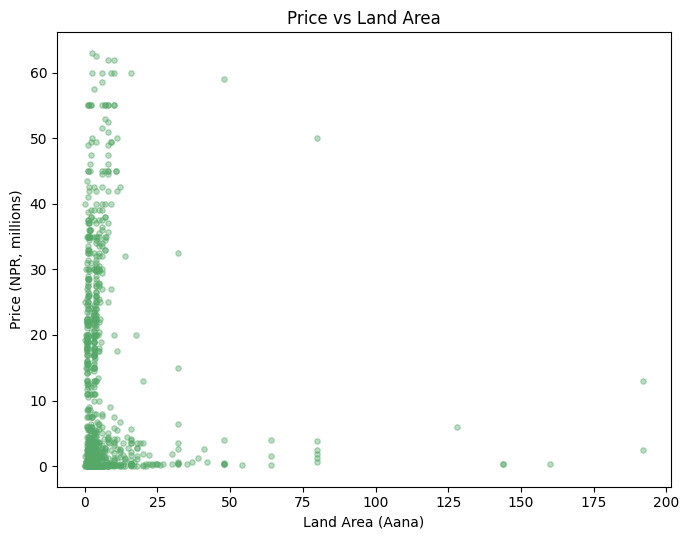

In [10]:
fig2, ax = plt.subplots(figsize=(7, 5.5))
sample = clean.sample(min(800, len(clean)), random_state=1)
ax.scatter(sample['Area_Aana'], sample['Price'] / 1e6, alpha=0.4, s=15, color='#55A868')
ax.set_xlabel('Land Area (Aana)')
ax.set_ylabel('Price (NPR, millions)')
ax.set_title('Price vs Land Area')
plt.tight_layout()
plt.savefig('visualizations2.png', dpi=140)
plt.show()

### 10. Export Cleaned Dataset

In [11]:
clean.to_csv('cleaned_housing_data.csv', index=False)
print("Saved cleaned_housing_data.csv with", len(clean), "rows")

Saved cleaned_housing_data.csv with 1868 rows
